# Desafio 1: O perfi l do Catálogo da Netflix
Dificuldade: Média.


Esse desafi o tem como objetivo responder algumas perguntas através da análise de dados, aprofundando o conhecimento em frequência e medidas.
Os dados que deverão ser utilizado nesse script foram baixados do kaggle, e podem ser acessados através do link:
https://www.kaggle.com/code/shivamb/netflix-shows-and-movies-exploratory-analysis

Este conjunto de dados consiste na lista de fi lmes e suas respectivas e suas informações.


Variáveis:


● show_id - id único do fi lme/série.
● title - título do fi lme ou série
● director - diretor do fi lme ou série
● cast - elenco do fi lme ou série
● country - país do fi lme ou série
● date_added - data que foi adicionado no Netfl ix
● reading score - ano de lançamento original do fi lme
● rating - classifi cação da televisão
● duration - duração total do fi lme ou série.
● listed_in - categoria ou gênero do fi lme ou série.
● description -descrição do fi lme ou série.
● type - tipo de fi lme ou série *texto em itálico*


Os dados são arquivos em .csv.

In [2]:
#Importando as bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Leitura do arquivo excel


df = pd.read_excel('netflix_titles_nov_2019.xlsx')
df.head(10)

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show
5,81172754,Crazy people,Moses Inwang,"Ramsey Nouah, Chigul, Sola Sobowale, Ireti Doy...",Nigeria,"November 29, 2019",2018,TV-14,107 min,"Comedies, International Movies, Thrillers",Nollywood star Ramsey Nouah learns that someon...,Movie
6,81120982,I Lost My Body,Jérémy Clapin,"Hakim Faris, Victoire Du Bois, Patrick d'Assum...",France,"November 29, 2019",2019,TV-MA,81 min,"Dramas, Independent Movies, International Movies","Romance, mystery and adventure intertwine as a...",Movie
7,81227195,Kalushi: The Story of Solomon Mahlangu,Mandla Dube,"Thabo Rametsi, Thabo Malema, Welile Nzuza, Jaf...",South Africa,"November 29, 2019",2016,TV-MA,107 min,"Dramas, International Movies",The life and times of iconic South African lib...,Movie
8,70205672,La Reina del Sur,NaN,"Kate del Castillo, Cristina Urgel, Alberto Jim...","United States, Spain, Colombia, Mexico",NaN,2019,TV-14,2 Seasons,"Crime TV Shows, International TV Shows, Spanis...",This compelling show tells the story of the le...,TV Show
9,81172841,Lagos Real Fake Life,Mike Ezuruonye,"Nonso Diobi, Mike Ezuruonye, Mercy Aigbe, Rex ...",NaN,"November 29, 2019",2018,TV-14,118 min,"Comedies, International Movies",Two mooching friends vie for the attention of ...,Movie


# Analisando valores nulos

In [4]:
# Verificaçao de nulos

df.isnull().sum()


# Observa-se uma boa quantidade de valores nulos em algumas colunas.

show_id            0
title              0
director        1901
cast             556
country          427
date_added       642
release_year       0
rating            10
duration           0
listed_in          0
description        0
type               0
dtype: int64

In [5]:
# Verificando o percentual de valores nulos

df.isnull().sum()/len(df)*100

show_id          0.000000
title            0.000000
director        32.568100
cast             9.525441
country          7.315402
date_added      10.998801
release_year     0.000000
rating           0.171321
duration         0.000000
listed_in        0.000000
description      0.000000
type             0.000000
dtype: float64

In [6]:
# Filtro para analisar os diretores que estão com valores nulos no df
# Observa-se que a maioria se trata do tipo 'TV show' (série).

df[df['director'].isnull()].head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show
8,70205672,La Reina del Sur,NaN,"Kate del Castillo, Cristina Urgel, Alberto Jim...","United States, Spain, Colombia, Mexico",NaN,2019,TV-14,2 Seasons,"Crime TV Shows, International TV Shows, Spanis...",This compelling show tells the story of the le...,TV Show
11,81094391,Sugar Rush Christmas,NaN,"Hunter March, Candace Nelson, Adriano Zumbo",United States,"November 29, 2019",2019,TV-PG,1 Season,Reality TV,"It's everything you love about ""Sugar Rush"" – ...",TV Show
13,81152641,The Charming Stepmom,NaN,"Shahkrit Yamnarm, View Wannarot Sontichai, Kri...",NaN,"November 29, 2019",2019,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",A quirky fashion student becomes the nanny of ...,TV Show


In [7]:
#Verificando a a quatidade de nulos de diretos por tipo

nulos_diretores = df[df['director'].isnull()]
nulos_diretores['type'].value_counts()

type
TV Show    1776
Movie       125
Name: count, dtype: int64

# Exploração Inicial

Quantas linhas e colunas tem o dataset?

In [8]:
tamanho = df.shape
print(f' Temos {tamanho[0]} linhas e {tamanho[1]} colunas')

 Temos 5837 linhas e 12 colunas


Quais são os tipos das variáveis e se há valores ausentes?

In [9]:
df.info()

# tipos das variáveis: categóricas(object) e numéricas (int)
# Sim, há valores ausentes. O dataset possui 5836 linhas, percebe-se a ausência de dadods em colunas que apresentam uma
# contagem menor de registros válidos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


# Análises de frequência:

Qual a proporção de fi lmes vs. séries no catálogo?

In [10]:
df['type'].value_counts(normalize = True) * 100



type
Movie      67.483296
TV Show    32.516704
Name: proportion, dtype: float64

In [11]:
df['type'].value_counts()


type
Movie      3939
TV Show    1898
Name: count, dtype: int64

Qual o gênero mais frequente?

In [12]:
df['listed_in'].dtypes

# é string

dtype('O')

In [13]:
# Dividi os generos por coluna para melhor analise.

df_generos = df['listed_in'].str.split(',', expand=True)
df_generos.columns = ['genero1', 'genero2', 'genero3']
df_generos.head(10)

,genero1,genero2,genero3
0,International TV Shows,Korean TV Shows,Romantic TV Shows
1,Documentaries,International Movies,None
2,Comedies,Dramas,International Movies
3,Dramas,Independent Movies,International Movies
4,Kids' TV,None,None
5,Comedies,International Movies,Thrillers
6,Dramas,Independent Movies,International Movies
7,Dramas,International Movies,None
8,Crime TV Shows,International TV Shows,Spanish-Language TV Shows
9,Comedies,International Movies,None


In [14]:
#Juntar colunas em uma só

## funções stack e melt

# vídeo auxiliar = https://www.youtube.com/watch?v=BUOy4RUUepg

# método melt? https://www.youtube.com/watch?v=686-m7PgyyU


contagem_generos = df_generos.stack().value_counts()
top10 = contagem_generos.head(10)
top10



 International Movies      1720
Dramas                      995
Comedies                    730
Documentaries               634
International TV Shows      546
Action & Adventure          532
 TV Dramas                  520
 Independent Movies         500
 Dramas                     493
 International TV Shows     420
Name: count, dtype: int64

In [15]:
generos_frequentes = contagem_generos.idxmax()
print(f'O genero mais frequente é : {generos_frequentes}')

O genero mais frequente é :  International Movies


# Análises estatísticas:
Qual a média, mediana e moda do tempo de duração dos filmes?

In [16]:
# o tempo de duração é string , entao, removi o 'min' e converti em inteiro para analise
# Considera-se apenas o tipo 'filme', pois alguns tipos de duração se trata de temporadas, como '1 season'

movies = df[df['type'] == 'Movie'].copy()
movies['duration'] = (movies['duration'].str.replace(' min', '')).astype(int)
movies.head(10)

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
5,81172754,Crazy people,Moses Inwang,"Ramsey Nouah, Chigul, Sola Sobowale, Ireti Doy...",Nigeria,"November 29, 2019",2018,TV-14,107,"Comedies, International Movies, Thrillers",Nollywood star Ramsey Nouah learns that someon...,Movie
6,81120982,I Lost My Body,Jérémy Clapin,"Hakim Faris, Victoire Du Bois, Patrick d'Assum...",France,"November 29, 2019",2019,TV-MA,81,"Dramas, Independent Movies, International Movies","Romance, mystery and adventure intertwine as a...",Movie
7,81227195,Kalushi: The Story of Solomon Mahlangu,Mandla Dube,"Thabo Rametsi, Thabo Malema, Welile Nzuza, Jaf...",South Africa,"November 29, 2019",2016,TV-MA,107,"Dramas, International Movies",The life and times of iconic South African lib...,Movie
9,81172841,Lagos Real Fake Life,Mike Ezuruonye,"Nonso Diobi, Mike Ezuruonye, Mercy Aigbe, Rex ...",NaN,"November 29, 2019",2018,TV-14,118,"Comedies, International Movies",Two mooching friends vie for the attention of ...,Movie
10,81172899,Payday,Cheta Chukwu,"Baaj Adebule, Ebiye Victor, Meg Otanwa, Bisola...",Nigeria,"November 29, 2019",2018,TV-MA,110,"Comedies, Independent Movies, International Mo...","After an expensive night out, two flatmates ge...",Movie
12,81172908,The Accidental Spy,Roger Russell,"Ramsey Nouah, Christine Allado, Ayo Makun, Emm...",Nigeria,"November 29, 2019",2017,TV-14,104,"Action & Adventure, Comedies, International Mo...","Nursing a broken heart, an IT specialist moves...",Movie
14,81172901,The Island,Toka McBaror,"Sambasa Nzeribe, Segun Arinze, Tokunbo Idowu, ...",Nigeria,"November 29, 2019",2018,TV-14,93,"Dramas, International Movies, Thrillers",When a colonel uncovers controversial intel ab...,Movie


In [17]:
# Média do tempo de duração dos
media = movies['duration'].mean().round(2)
print (f'A media de duraçao dos filmes é de {media} minutos')

A media de duraçao dos filmes é de 98.03 minutos


In [18]:
moda = movies['duration'].mode()
print (f'A moda de duraçao dos filmes é de {moda} minutos')

A moda de duraçao dos filmes é de 0    90
Name: duration, dtype: int64 minutos


In [19]:
mediana = movies['duration'].median()
print (f'A mediana de duraçao dos filmes é de {mediana} minutos')

A mediana de duraçao dos filmes é de 97.0 minutos


Qual o fi lme mais curto e mais longo?

In [20]:
movies.loc[movies['duration'].idxmax()]

show_id                                                  80988062
title                                  Black Mirror: Bandersnatch
director                                                      NaN
cast            Fionn Whitehead, Will Poulter, Craig Parkinson...
country                                             United States
date_added                                      December 28, 2018
release_year                                                 2018
rating                                                      TV-MA
duration                                                      312
listed_in          Dramas, International Movies, Sci-Fi & Fantasy
description     In 1984, a young programmer begins to question...
type                                                        Movie
Name: 2160, dtype: object

In [21]:
movies.loc[movies['duration'] == movies['duration'].max(), ['title', 'duration']]

,title,duration
2160,Black Mirror: Bandersnatch,312


In [22]:
movies.loc[movies['duration'] == movies['duration'].min(), ['title', 'duration']]

,title,duration
1185,Silent,3


In [23]:
# expand- transformar em colunas separadas

pais = df['country'].str.split(',', expand=True)

pais

,0,1,2,3,4,5,6,7,8,9,10,11
0,South Korea,None,None,None,None,None,None,None,None,None,None,None
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,India,None,None,None,None,None,None,None,None,None,None,None
3,France,Senegal,Belgium,None,None,None,None,None,None,None,None,None
4,Canada,United Kingdom,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
5832,United States,None,None,None,None,None,None,None,None,None,None,None
5833,United States,None,None,None,None,None,None,None,None,None,None,None
5834,Denmark,None,None,None,None,None,None,None,None,None,None,None
5835,United States,None,None,None,None,None,None,None,None,None,None,None


In [24]:
contagem_pais = pais.stack().str.strip().value_counts()
top5 = contagem_pais.head(5)
top5

United States     2421
India              753
United Kingdom     559
Canada             300
France             255
Name: count, dtype: int64

# Visualização de dados

Criar um gráfico de barras para mostrar a quantidade de títulos por gênero.

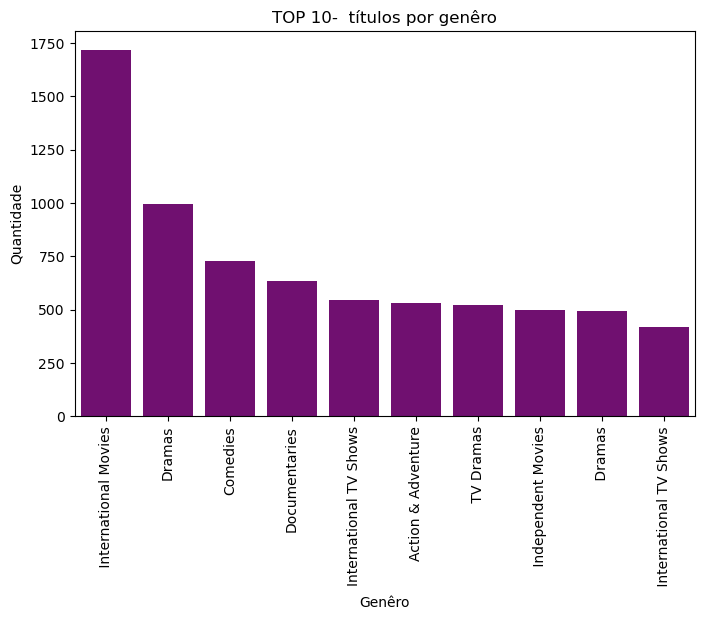

In [25]:
#inches (largura x altura)
plt.figure (figsize = (8,5))

# com SEABORN


# Chamamos o SNS para escolher o tipo de gráfico, barras (barplot)
# optei por demonstrar apenas o top 10 para melhor visualização

sns.barplot(x = top10.index, y = top10.values, color = 'purple') # tipo de gráfico e configurações

plt.title('TOP 10-  títulos por genêro')  # titulo do gráfico
plt.xlabel('Genêro')   # titulo do eixo x
plt.ylabel('Quantidade')  # titulo do eixo y
plt.xticks(rotation = 90)  # rotaçao do texto eixo x
plt.show()

Criar um gráfi co de barras para mostrar a quantidade de títulos por gênero.


biblioteca : https://matplotlib.org/stable/


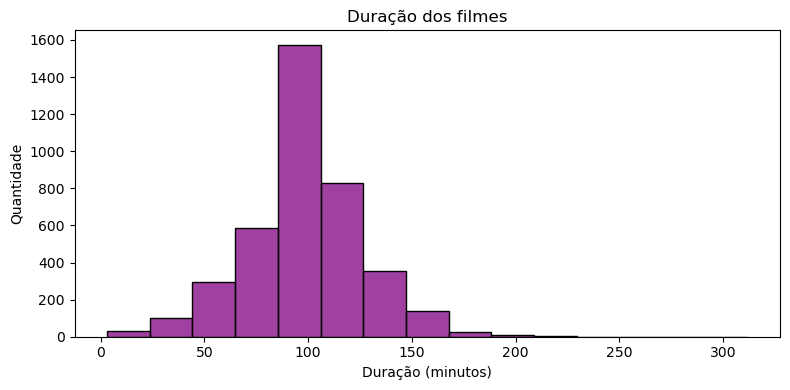

In [26]:
plt.figure (figsize = (8,4))  # tamanho do gráfico

# tipo do gráfico
# configurações: onde estão os dados, eixo x, bins e cor
# bins - numero de intervalos
sns.histplot (data = movies,
              x = 'duration',
              bins = 15,
              color = 'purple')

plt.title('Duração dos filmes') # titulo
plt.xlabel('Duração (minutos)')  # definindo nome do eixo x
plt.ylabel('Quantidade')  # definindo nome do eixo y
plt.tight_layout()  # ajusta o layout
plt.show()  # Exibiçao
#

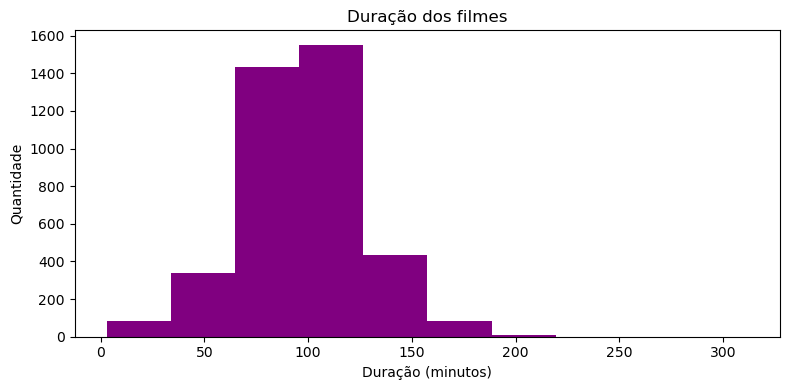

In [27]:
plt.figure (figsize = (8,4))  # tamanho do gráfico

# tipo do gráfico
# configurações: onde estão os dados, eixo x, bins e cor
# bins - numero de intervalos
plt.hist(data = movies,
         x = 'duration',
         color = 'purple')

plt.title('Duração dos filmes') # titulo
plt.xlabel('Duração (minutos)')  # definindo nome do eixo x
plt.ylabel('Quantidade')  # definindo nome do eixo y
plt.tight_layout()  # ajusta o layout
plt.show()  # Exibiçao
#

# ATIVIDADE EXTRA  

Quais são os 5 países que possuem mais produções no catálogo?

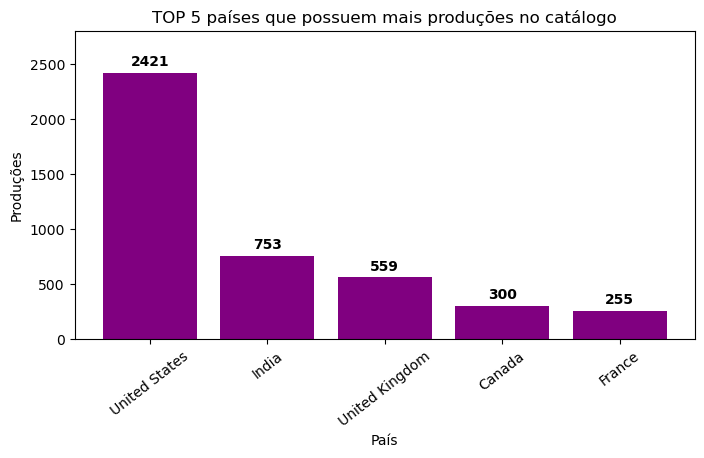

In [28]:
#inches (largura x altura)
plt.figure (figsize = (8,4))

barra = plt.bar(x = top5.index, height = top5.values, color = 'purple')

plt.title('TOP 5 países que possuem mais produções no catálogo')
plt.xlabel('País')
plt.ylabel('Produções')
plt.xticks(rotation = 38)  # rotação dos textos

plt.ylim(0,2800) # limitando o eixo y para ter espaçamento do rótulo.

plt.bar_label(barra, padding = 3, fontweight = 'bold') # espaçamento, fonte
plt.tight_layout  # ajusta as margens, layots
plt.show()